1. Chụp mặt của 2 thành viên, mỗi người 10 ảnh (nghiêng trái - 2, trực diện - 2, quay trái - 2, quay phải - 2 , ngẩng lên cúi xuống - 2) => Tập training 2 phân lớp: thành viên 1 và 2
2. Xác định eigenfaces, fisherfaces, meanface.
3. Nhận diện gương mặt với eigenface và fisherface ở trên.
4. Đánh giá độ chính xác của từng phương pháp.

In [1]:
import os
import shutil
from pathlib import Path
import numpy as np
import cv2 as cv
from PIL import Image
import matplotlib.pyplot as plt

!pip install --upgrade gdown -q

drive_link = "https://drive.google.com/drive/folders/1gghke-7bEsaa2APu_xBqbzQUQe7e-gIL?usp=sharing"
expected_root = Path("/content/LabIP")

if expected_root.exists():
    shutil.rmtree(expected_root)

print("Dang tai du lieu tu Google Drive...")
!gdown --folder $drive_link -q
print("Tai xong.")

def find_data_root():
    candidates = [
        Path("/content/LabIP"),
        Path("LabIP"),
        Path("./LabIP"),
    ]
    for c in candidates:
        if (c / "train").exists() and (c / "test").exists():
            return c
    for base in [Path("/content"), Path(".")]:
        if not base.exists():
            continue
        for p in base.rglob("*"):
            if p.is_dir() and (p / "train").exists() and (p / "test").exists():
                return p
    return None

DATA_ROOT = find_data_root()
if DATA_ROOT is not None:
    print(f"Data root: {DATA_ROOT}")
    print(f"Train dir: {DATA_ROOT / 'train'}")
    print(f"Test dir: {DATA_ROOT / 'test'}")
else:
    print("Khong tim thay folder du lieu co cau truc train/test sau khi tai.")

Dang tai du lieu tu Google Drive...
Tai xong.
Data root: /content/LabIP
Train dir: /content/LabIP/train
Test dir: /content/LabIP/test


In [2]:
if DATA_ROOT is None:
    print("No data root found.")
else:
    train_dir = DATA_ROOT / "train"
    test_dir = DATA_ROOT / "test"
    print("Train exists:", train_dir.exists())
    print("Test exists:", test_dir.exists())
    if train_dir.exists():
        print("Train entries:", sorted([p.name for p in train_dir.iterdir()])[:20])
    if test_dir.exists():
        print("Test entries:", sorted([p.name for p in test_dir.iterdir()])[:20])

Train exists: True
Test exists: True
Train entries: ['001_down_1.jpg', '001_front_1.jpg', '001_front_2.jpg', '001_tiltLeft_1.jpg', '001_tiltRight_1.jpg', '001_turnLeft_1.jpg', '001_turnLeft_2.jpg', '001_turnRight_1.jpg', '001_turnRight_2.jpg', '001_up_1.jpg', '002_down_1.JPG', '002_front_1.JPG', '002_front_2.JPG', '002_tiltLeft_1.JPG', '002_tiltRight_1.JPG', '002_turnLeft_1.JPG', '002_turnLeft_2.JPG', '002_turnRight_1.JPG', '002_turnRight_2.JPG', '002_up_1.JPG']
Test entries: ['001_test_1.jpg', '001_test_2.jpg', '001_test_3.jpg', '001_test_4.jpg', '001_test_5.jpg', '001_test_6.jpg', '001_test_7.jpg', '001_test_8.jpg', '002_test 4.JPG', '002_test_1.JPG', '002_test_2.JPG', '002_test_3.JPG', '002_test_5.JPG']


In [3]:
def count_images_under(root_dir):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    if root_dir is None or not root_dir.exists():
        return 0
    return sum(1 for f in root_dir.rglob("*") if f.suffix.lower() in exts)

if DATA_ROOT is None:
    print("No data root found.")
else:
    n_train = count_images_under(DATA_ROOT / "train")
    n_test = count_images_under(DATA_ROOT / "test")
    print(f"Total train images: {n_train}")
    print(f"Total test images: {n_test}")

Total train images: 20
Total test images: 13


In [4]:
# !ls /content/LabIP/test

In [5]:
# !ls /content/LabIP/train

Skip /content/LabIP/test/001_test_2.jpg: cannot identify image file '/content/LabIP/test/001_test_2.jpg'
Using existing train/test folders.
Train: 20 images, classes: ['001' '002']
Test: 12 images, classes: ['001' '002']
Train class counts: {'001': 10, '002': 10}


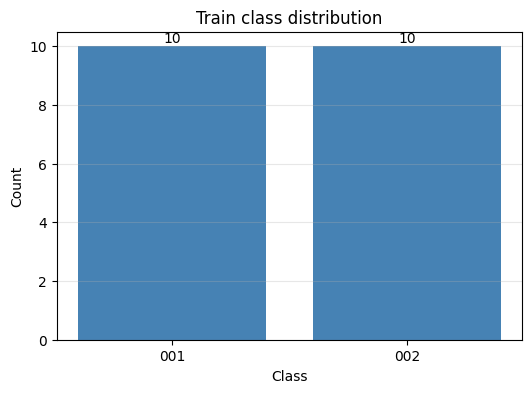

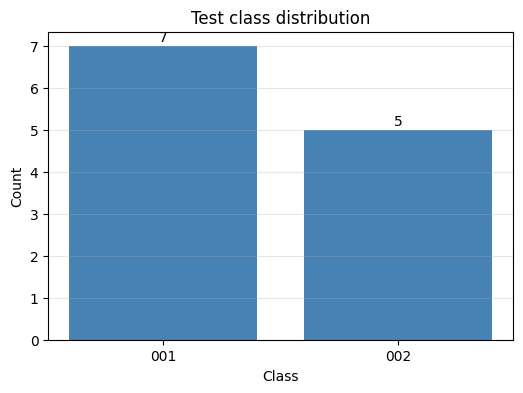

In [6]:
import glob
from PIL import ImageOps

def parse_label(filepath):
    base = os.path.basename(filepath)
    if "_" in base:
        return base.split("_")[0]
    return Path(filepath).parent.name

def collect_image_files(root_dir):
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    files = []
    for p in Path(root_dir).rglob("*"):
        if p.suffix.lower() in exts:
            files.append(str(p))
    return sorted(files)

def load_images_from_files(files, img_size=(128, 128)):
    if not files:
        raise FileNotFoundError("Empty file list.")
    X, y, valid_files = [], [], []
    for f in files:
        try:
            img = Image.open(f)
            # Tự động xoay ảnh dựa trên EXIF (sửa lỗi ảnh bị quay ngang)
            img = ImageOps.exif_transpose(img)
            img = img.convert("L")
            img_np = np.array(img)
            img_np = cv.resize(img_np, img_size, interpolation=cv.INTER_AREA)
            X.append(img_np)
            y.append(parse_label(f))
            valid_files.append(f)
        except Exception as e:
            print(f"Skip {f}: {e}")
    if len(X) == 0:
        raise ValueError("No images could be loaded. Check file paths.")
    return np.stack(X, axis=0), np.array(y), valid_files

def load_images(root_dir, img_size=(128, 128)):
    files = collect_image_files(root_dir)
    if not files:
        raise FileNotFoundError(f"No images found under: {root_dir}")
    return load_images_from_files(files, img_size=img_size)

def split_by_class_fixed(files, labels, target_classes=("001", "002"), train_per_class=10, min_test_per_class=1, seed=42):
    rng = np.random.default_rng(seed)
    files = np.array(files)
    labels = np.array(labels)
    train_files, test_files = [], []
    train_labels, test_labels = [], []
    for cls in target_classes:
        idx = np.where(labels == cls)[0]
        if len(idx) < train_per_class:
            raise ValueError(f"Class {cls} has only {len(idx)} images, need >= {train_per_class}.")
        rng.shuffle(idx)
        cls_train_idx = idx[:train_per_class]
        cls_rest_idx = idx[train_per_class:]
        cls_test_idx = cls_rest_idx.tolist()
        if len(cls_test_idx) < min_test_per_class:
            extra_need = min_test_per_class - len(cls_test_idx)
            cls_test_idx += cls_train_idx[-extra_need:].tolist()
        for i in cls_train_idx:
            train_files.append(files[i])
            train_labels.append(labels[i])
        for i in cls_test_idx:
            test_files.append(files[i])
            test_labels.append(labels[i])
    return train_files, np.array(train_labels), test_files, np.array(test_labels)

def show_faces(face_vectors, title, img_shape, max_show=6):
    if len(face_vectors) == 0:
        print(f"{title}: empty")
        return
    n = min(max_show, len(face_vectors))
    cols = min(6, n)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(2 * cols, 2 * rows))
    for i in range(n):
        face = face_vectors[i].reshape(img_shape)
        face = (face - face.min()) / (face.max() - face.min() + 1e-8)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

def plot_label_distribution(labels, title):
    uniq, counts = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6, 4))
    plt.bar(uniq, counts, color="steelblue")
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    for i, c in enumerate(counts):
        plt.text(i, c + 0.05, str(c), ha="center", va="bottom")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

def check_assignment_constraint(y_train, expected_classes=("001", "002"), expected_each=10):
    uniq, counts = np.unique(y_train, return_counts=True)
    count_map = dict(zip(uniq.tolist(), counts.tolist()))
    print("Train class counts:", count_map)
    for cls in expected_classes:
        if cls not in count_map:
            print(f"[CANH BAO] Thieu class {cls} trong train.")
        elif count_map[cls] != expected_each:
            print(f"[CANH BAO] Class {cls} co {count_map[cls]} anh train (yeu cau {expected_each}).")
    if len(uniq) != len(expected_classes):
        print(f"[CANH BAO] So lop train = {len(uniq)} (yeu cau {len(expected_classes)}).")

def pca_faces(X, num_components):
    mean = X.mean(axis=0)
    Xc = X - mean
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    eigvecs = Vt[:num_components]
    return mean, eigvecs

def fisherfaces(X, y):
    labels = np.unique(y)
    c = len(labels)
    if c < 2:
        return None, None
    n_samples, d = X.shape
    pca_dim = min(n_samples - c, d)
    if pca_dim < 1:
        return None, None
    mean = X.mean(axis=0)
    Xc = X - mean
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    pca_vecs = Vt[:pca_dim]
    Z = Xc @ pca_vecs.T
    overall_mean = Z.mean(axis=0)
    Sw = np.zeros((pca_dim, pca_dim), dtype=np.float64)
    Sb = np.zeros((pca_dim, pca_dim), dtype=np.float64)
    for label in labels:
        Zi = Z[y == label]
        if Zi.size == 0:
            continue
        mean_i = Zi.mean(axis=0)
        diff = (mean_i - overall_mean).reshape(-1, 1)
        Sw += (Zi - mean_i).T @ (Zi - mean_i)
        Sb += Zi.shape[0] * (diff @ diff.T)
    mat = np.linalg.pinv(Sw) @ Sb
    eigvals, eigvecs = np.linalg.eig(mat)
    order = np.argsort(-eigvals.real)
    eigvecs = eigvecs[:, order].real
    n_comp = min(c - 1, eigvecs.shape[1])
    lda_vecs = eigvecs[:, :n_comp]
    W = pca_vecs.T @ lda_vecs
    return mean, W

def nearest_neighbor(train_proj, train_labels, test_proj):
    preds = []
    for p in test_proj:
        dists = np.linalg.norm(train_proj - p, axis=1)
        preds.append(train_labels[np.argmin(dists)])
    return np.array(preds)

img_size = (128, 128)
READY = False
X_train = None
X_test = None
y_train = None
y_test = None
img_shape = None
train_files = []
test_files = []

if DATA_ROOT is None:
    print("No data root found. Skip training pipeline.")
else:
    target_classes = ("001", "002")
    train_dir = os.path.join(DATA_ROOT, "train")
    test_dir = os.path.join(DATA_ROOT, "test")
    try:
        use_direct_split = False
        if os.path.isdir(train_dir) and os.path.isdir(test_dir):
            X_train_imgs, y_train_tmp, train_files_tmp = load_images(train_dir, img_size=img_size)
            X_test_imgs, y_test_tmp, test_files_tmp = load_images(test_dir, img_size=img_size)
            train_ok = set(np.unique(y_train_tmp)) >= set(target_classes)
            test_ok = set(np.unique(y_test_tmp)) >= set(target_classes)
            if train_ok and test_ok:
                X_train_imgs, y_train, train_files = X_train_imgs, y_train_tmp, train_files_tmp
                X_test_imgs, y_test, test_files = X_test_imgs, y_test_tmp, test_files_tmp
                use_direct_split = True
                print("Using existing train/test folders.")
            else:
                print("Train/Test folders do not include both classes 001 and 002. Fallback to auto split from all images.")

        if not use_direct_split:
            X_all_imgs, y_all, all_files = load_images(DATA_ROOT, img_size=img_size)
            train_files, y_train, test_files, y_test = split_by_class_fixed(
                all_files, y_all, target_classes=target_classes, train_per_class=10, min_test_per_class=1, seed=42
            )
            X_train_imgs, _, _ = load_images_from_files(train_files, img_size=img_size)
            X_test_imgs, _, _ = load_images_from_files(test_files, img_size=img_size)
            print("Using auto split from all data: 10 train/class + at least 1 test/class.")

        print(f"Train: {len(X_train_imgs)} images, classes: {np.unique(y_train)}")
        print(f"Test: {len(X_test_imgs)} images, classes: {np.unique(y_test)}")

        X_train = X_train_imgs.reshape(len(X_train_imgs), -1).astype(np.float32)
        X_test = X_test_imgs.reshape(len(X_test_imgs), -1).astype(np.float32) if len(X_test_imgs) > 0 else np.empty((0, X_train.shape[1]), dtype=np.float32)
        img_shape = X_train_imgs.shape[1:]

        check_assignment_constraint(y_train, expected_classes=target_classes, expected_each=10)
        plot_label_distribution(y_train, "Train class distribution")
        if len(y_test) > 0:
            plot_label_distribution(y_test, "Test class distribution")

        READY = True
    except Exception as e:
        print(f"Khong the khoi tao du lieu: {e}")
        READY = False

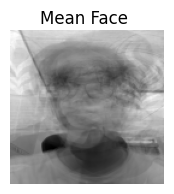

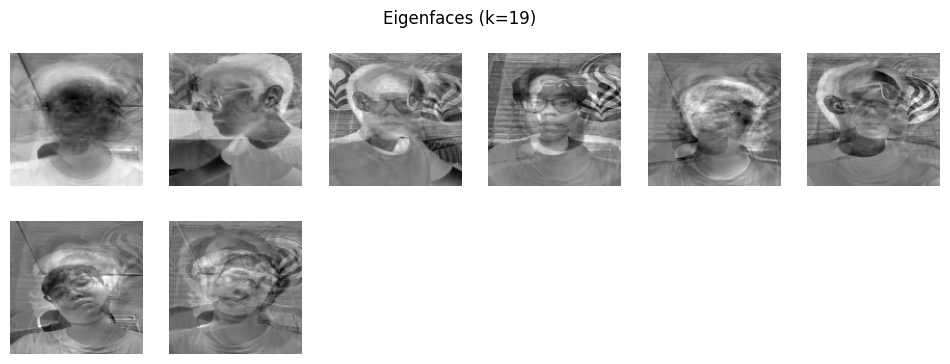

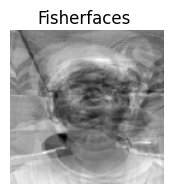

In [7]:
if not READY:
    print("Data not ready. Skip Q2.")
else:
    mean_face = X_train.mean(axis=0)
    k = min(20, X_train.shape[0] - 1) if X_train.shape[0] > 1 else 1
    mean_pca, eigfaces = pca_faces(X_train, k)
    mean_fisher, fisher_W = fisherfaces(X_train, y_train)

    show_faces([mean_face], "Mean Face", img_shape, max_show=1)
    show_faces(eigfaces, f"Eigenfaces (k={k})", img_shape, max_show=8)
    if fisher_W is not None:
        show_faces(fisher_W.T, "Fisherfaces", img_shape, max_show=8)
    else:
        print("Fisherfaces: need at least 2 classes.")

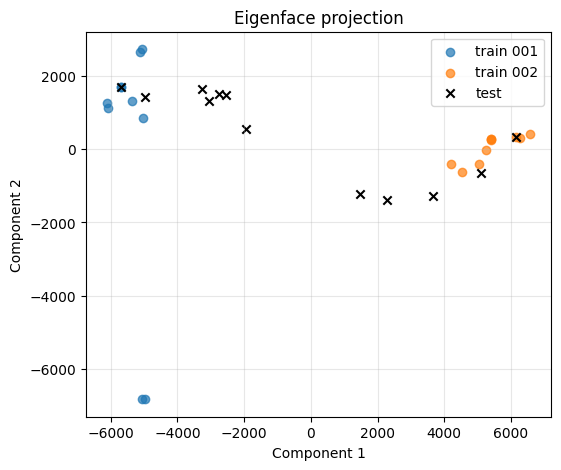

Fisherface projection: need at least 2 components to plot.


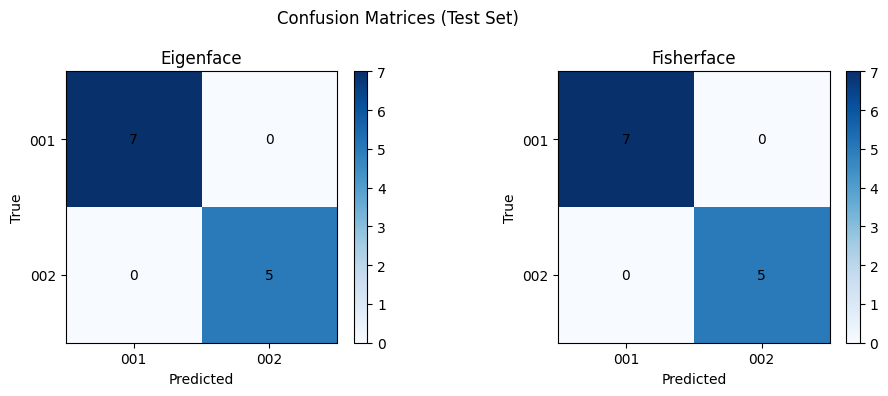

Eigenface predictions: ['001' '001' '001' '001' '001' '001' '001' '002' '002' '002' '002' '002']
Fisherface predictions: ['001' '001' '001' '001' '001' '001' '001' '002' '002' '002' '002' '002']


In [8]:
preds_eig = None
preds_f = None
cm_eig = None
cm_f = None


def plot_projection_scores(train_proj, train_labels, test_proj, title):
    if train_proj.shape[1] < 2:
        print(f"{title}: need at least 2 components to plot.")
        return
    plt.figure(figsize=(6, 5))
    for lab in np.unique(train_labels):
        idx = train_labels == lab
        plt.scatter(train_proj[idx, 0], train_proj[idx, 1], alpha=0.7, label=f"train {lab}")
    if test_proj is not None and len(test_proj) > 0:
        plt.scatter(test_proj[:, 0], test_proj[:, 1], c="k", marker="x", label="test")
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def confusion_matrix_np(y_true, y_pred, labels):
    label_to_idx = {lab: i for i, lab in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.int32)
    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[t], label_to_idx[p]] += 1
    return cm


def plot_confusion_matrices(cms, labels, titles, suptitle):
    n = len(cms)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, cm, title in zip(axes, cms, titles):
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


if not READY or X_test.shape[0] == 0:
    print("No test data found.")
else:
    labels_sorted = np.unique(y_train)
    k_train = min(20, X_train.shape[0] - 1) if X_train.shape[0] > 1 else 1
    mean_train, eig_train = pca_faces(X_train, k_train)
    train_proj = (X_train - mean_train) @ eig_train.T
    test_proj = (X_test - mean_train) @ eig_train.T
    preds_eig = nearest_neighbor(train_proj, y_train, test_proj)

    plot_projection_scores(train_proj, y_train, test_proj, "Eigenface projection")
    cm_eig = confusion_matrix_np(y_test, preds_eig, labels_sorted)

    mean_f_train, fisher_W_train = fisherfaces(X_train, y_train)
    if fisher_W_train is None:
        print("Fisherface recognition: need at least 2 classes with >=2 samples each.")
    else:
        train_proj_f = (X_train - mean_f_train) @ fisher_W_train
        test_proj_f = (X_test - mean_f_train) @ fisher_W_train
        preds_f = nearest_neighbor(train_proj_f, y_train, test_proj_f)

        plot_projection_scores(train_proj_f, y_train, test_proj_f, "Fisherface projection")
        cm_f = confusion_matrix_np(y_test, preds_f, labels_sorted)

    cms = [cm_eig]
    titles = ["Eigenface"]
    if cm_f is not None:
        cms.append(cm_f)
        titles.append("Fisherface")
    plot_confusion_matrices(cms, labels_sorted, titles, "Confusion Matrices (Test Set)")

    print("Eigenface predictions:", preds_eig)
    if preds_f is not None:
        print("Fisherface predictions:", preds_f)

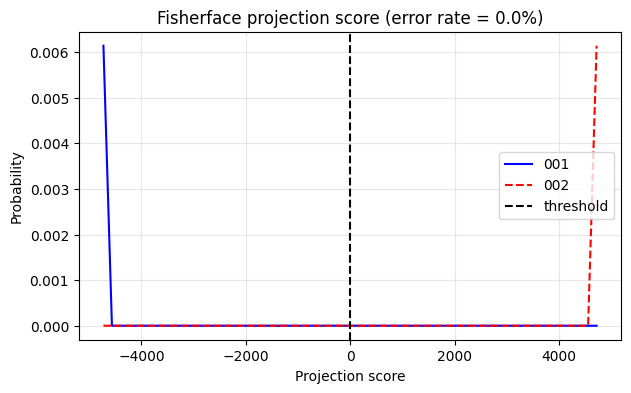

In [12]:
# Fisherface projection score distribution (2 classes)
if not READY or X_test.shape[0] == 0:
    print("No test data found.")
else:
    labels_sorted = np.unique(y_train)
    if len(labels_sorted) != 2:
        print("This plot expects exactly 2 classes.")
    else:
        mean_f, W = fisherfaces(X_train, y_train)
        if W is None or W.shape[1] < 1:
            print("Fisherface not available.")
        else:
            w = W[:, 0]
            train_scores = (X_train - mean_f) @ w
            test_scores = (X_test - mean_f) @ w

            m0 = train_scores[y_train == labels_sorted[0]].mean()
            m1 = train_scores[y_train == labels_sorted[1]].mean()
            thresh = (m0 + m1) / 2.0
            if m0 < m1:
                pred_test = np.where(test_scores >= thresh, labels_sorted[1], labels_sorted[0])
            else:
                pred_test = np.where(test_scores >= thresh, labels_sorted[0], labels_sorted[1])
            err_rate = float((pred_test != y_test).mean())

            lo = min(train_scores.min(), test_scores.min())
            hi = max(train_scores.max(), test_scores.max())
            bins = np.linspace(lo, hi, 60)

            plt.figure(figsize=(7, 4))
            styles = ["b-", "r--"]
            for cls, style in zip(labels_sorted, styles):
                s = train_scores[y_train == cls]
                hist, edges = np.histogram(s, bins=bins, density=True)
                centers = (edges[:-1] + edges[1:]) / 2
                plt.plot(centers, hist, style, label=str(cls))

            plt.axvline(thresh, color="k", linestyle="--", label="threshold")
            plt.title(f"Fisherface projection score (error rate = {err_rate*100:.1f}%)")
            plt.xlabel("Projection score")
            plt.ylabel("Probability")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()

In [11]:
def compute_metrics(y_true, y_pred, labels):
    label_to_idx = {lab: i for i, lab in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.int32)
    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[t], label_to_idx[p]] += 1
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp

    def safe_div(a, b):
        return a / b if b != 0 else 0.0

    precision = [safe_div(tp[i], tp[i] + fp[i]) for i in range(len(labels))]
    recall = [safe_div(tp[i], tp[i] + fn[i]) for i in range(len(labels))]
    f1 = [safe_div(2 * precision[i] * recall[i], precision[i] + recall[i]) for i in range(len(labels))]

    acc = safe_div(tp.sum(), cm.sum())
    return acc, float(np.mean(precision)), float(np.mean(recall)), float(np.mean(f1))


def print_metrics_table(rows):
    print("Method     | Acc    | Prec   | Recall | F1")
    print("-" * 46)
    for name, acc, prec, rec, f1 in rows:
        print(f"{name:<10} | {acc*100:6.2f} | {prec*100:6.2f} | {rec*100:6.2f} | {f1*100:6.2f}")


if not READY or y_test is None or len(y_test) == 0:
    print("Accuracy: not available.")
else:
    labels_sorted = np.unique(y_train)
    rows = []

    if preds_eig is not None:
        acc, prec, rec, f1 = compute_metrics(y_test, preds_eig, labels_sorted)
        rows.append(("Eigenface", acc, prec, rec, f1))
    else:
        print("Eigenface metrics: not available.")

    if preds_f is not None:
        acc, prec, rec, f1 = compute_metrics(y_test, preds_f, labels_sorted)
        rows.append(("Fisherface", acc, prec, rec, f1))
    else:
        print("Fisherface metrics: not available.")

    if rows:
        print_metrics_table(rows)

Method     | Acc    | Prec   | Recall | F1
----------------------------------------------
Eigenface  | 100.00 | 100.00 | 100.00 | 100.00
Fisherface | 100.00 | 100.00 | 100.00 | 100.00


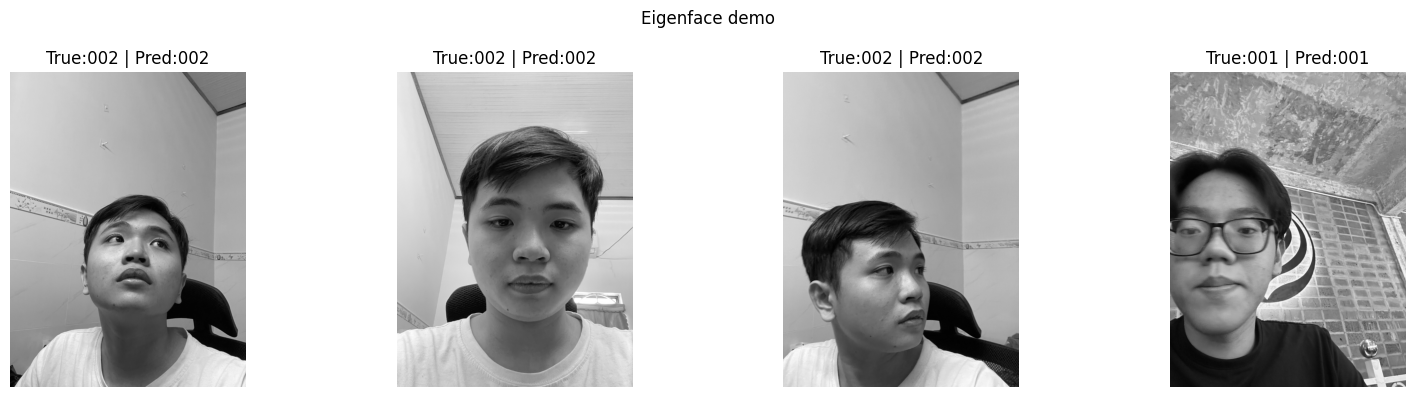

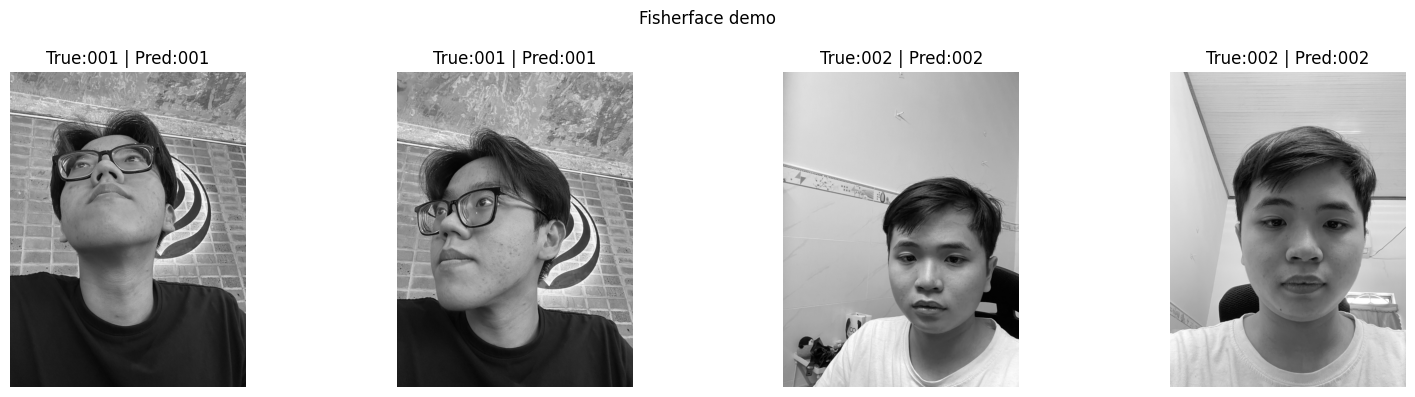

In [10]:
from PIL import ImageOps


def show_random_predictions(test_files, y_test, preds, n=2, title="Demo"):
    if preds is None or len(preds) == 0:
        print(f"{title}: no predictions")
        return
    n = min(n, len(test_files))
    if n == 0:
        print(f"{title}: no test files")
        return
    idxs = np.random.choice(len(test_files), size=n, replace=False)
    plt.figure(figsize=(4 * n, 4))
    for i, idx in enumerate(idxs):
        img = Image.open(test_files[idx])
        img = ImageOps.exif_transpose(img).convert("L")
        plt.subplot(1, n, i + 1)
        plt.imshow(np.array(img), cmap="gray")
        plt.title(f"True:{y_test[idx]} | Pred:{preds[idx]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


N = 4
if not READY or X_test.shape[0] == 0:
    print("No test data found.")
else:
    if preds_eig is not None:
        show_random_predictions(test_files, y_test, preds_eig, n=N, title="Eigenface demo")
    if preds_f is not None:
        show_random_predictions(test_files, y_test, preds_f, n=N, title="Fisherface demo")